# 04. Expected Goals Lambda Adjustment

**Stage:** 04_adjustments  
**Inputs:** `data/processed/ratings.parquet`, `data/processed/absences.parquet`, `src/config/config.yaml`  
**Outputs:** `data/processed/adjusted_lambdas.parquet`  

This notebook applies config-driven positional absence effects to the two Poisson lambdas while preserving one row per fixture. FWD/MID absences reduce the affected team's lambda; GK/DEF absences increase the opponent's lambda. The `min_absence_matches` empirical override remains deferred.

In [5]:
# Load configuration and imports
%load_ext autoreload
%autoreload 2
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / "src" / "config" / "loader.py").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from src.config.loader import load_config
from src.adjustments.lambda_adjustment import build_adjusted_lambdas

config = load_config()
processed_dir = repo_root / "data" / "processed"
ratings_file = processed_dir / "ratings.parquet"
absences_file = processed_dir / "absences.parquet"
if not ratings_file.exists():
    raise FileNotFoundError(f"Ratings artifact is missing: {ratings_file}")
if not absences_file.exists():
    raise FileNotFoundError(f"Absence artifact is missing: {absences_file}")
ratings_df = pd.read_parquet(ratings_file)
absences_df = pd.read_parquet(absences_file)
print(f"Loaded ratings: {len(ratings_df)} fixtures")
print(f"Loaded absences: {len(absences_df)} rows")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loaded ratings: 760 fixtures
Loaded absences: 2755 rows


In [6]:
# Verify the two-season rating coverage before applying adjustments
ratings_df["date"] = pd.to_datetime(ratings_df["date"])
print("Rating season counts:")
print(ratings_df["season"].value_counts().sort_index())
print(f"Rating date range: {ratings_df['date'].min()} to {ratings_df['date'].max()}")

Rating season counts:
season
2425    380
2526    380
Name: count, dtype: int64
Rating date range: 2024-08-16 00:00:00 to 2026-05-24 00:00:00


In [7]:
# Build one adjusted row per rated fixture
adjusted_lambdas_df = build_adjusted_lambdas(ratings_df, absences_df, config)
unmatched_absences_df = adjusted_lambdas_df.attrs["unmatched_absences"]
if not unmatched_absences_df.empty:
    print(f"WARNING: {len(unmatched_absences_df)} absence rows have no matching rated fixture.")
    display(unmatched_absences_df[["fixture_id", "date", "team", "player_name"]].head())
else:
    print("All absence rows matched a rated fixture by provider ID or normalized date/team reconciliation.")

output_columns = [
    "fixture_id", "home_team", "away_team",
    "base_home_lambda", "adjusted_home_lambda",
    "base_away_lambda", "adjusted_away_lambda",
    "num_home_absences_applied", "num_away_absences_applied",
]
adjusted_lambdas_df = adjusted_lambdas_df[output_columns].copy()
adjusted_lambdas_df.attrs = {}
output_file = processed_dir / "adjusted_lambdas.parquet"
adjusted_lambdas_df.to_parquet(output_file, index=False)
print(f"Saved {len(adjusted_lambdas_df)} adjusted fixture rows to {output_file}")

All absence rows matched a rated fixture by provider ID or normalized date/team reconciliation.
Saved 760 adjusted fixture rows to /Users/mac/Documents/Projects/SportsBettingPoisson+ML/data/processed/adjusted_lambdas.parquet


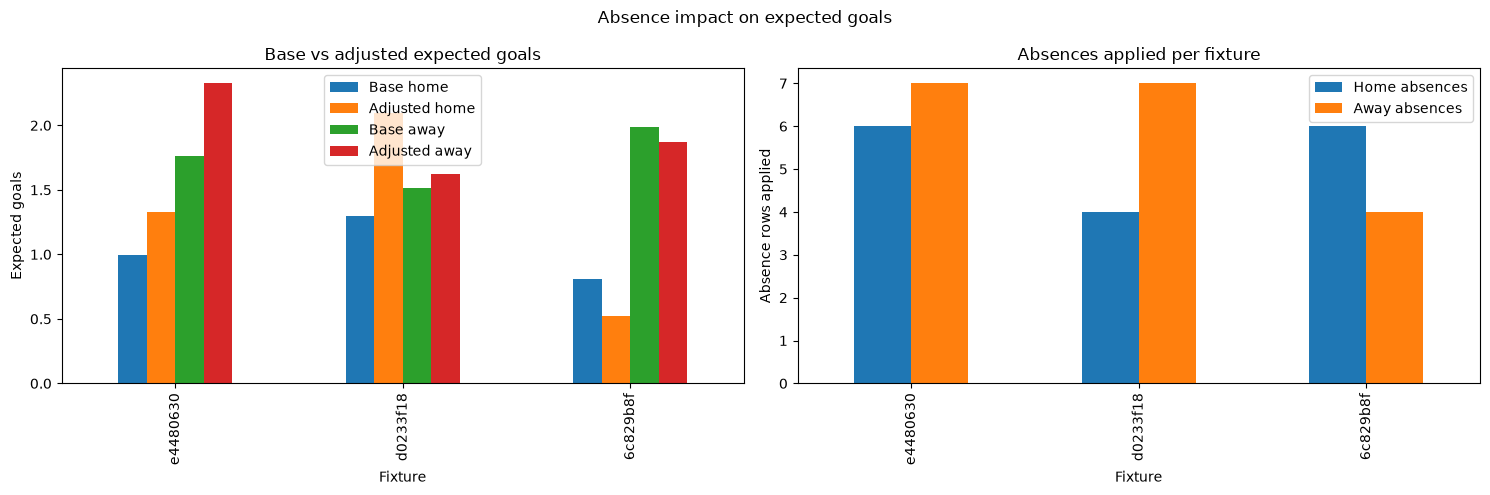

,fixture_id,home_team,away_team,base_home_lambda,adjusted_home_lambda,base_away_lambda,adjusted_away_lambda,num_home_absences_applied,num_away_absences_applied
137,e4480630,Southampton,Chelsea,0.996,1.326202,1.765,2.325666,6,7
750,d0233f18,Crystal Palace,Arsenal,1.298,2.093414,1.515,1.625519,4,7
217,6c829b8f,Ipswich Town,Manchester City,0.809,0.519795,1.985,1.868250,6,4


In [8]:
# Compare lambda changes and applied absence counts for three representative fixtures
comparison = adjusted_lambdas_df.copy()
comparison["total_absences_applied"] = (
    comparison["num_home_absences_applied"]
    + comparison["num_away_absences_applied"]
)
comparison = comparison.sort_values(
    ["total_absences_applied", "fixture_id"],
    ascending=[False, True],
).head(3)

if comparison.empty or comparison["total_absences_applied"].sum() == 0:
    raise ValueError("No fixtures with applied absences are available for visualization.")

lambda_plot = comparison.set_index("fixture_id")[[
    "base_home_lambda",
    "adjusted_home_lambda",
    "base_away_lambda",
    "adjusted_away_lambda",
]]
absence_plot = comparison.set_index("fixture_id")[[
    "num_home_absences_applied",
    "num_away_absences_applied",
]]

figure, axes = plt.subplots(1, 2, figsize=(15, 5))
lambda_plot.plot(kind="bar", ax=axes[0], title="Base vs adjusted expected goals")
axes[0].set_ylabel("Expected goals")
axes[0].set_xlabel("Fixture")
axes[0].legend(["Base home", "Adjusted home", "Base away", "Adjusted away"])
absence_plot.plot(kind="bar", ax=axes[1], title="Absences applied per fixture")
axes[1].set_ylabel("Absence rows applied")
axes[1].set_xlabel("Fixture")
axes[1].legend(["Home absences", "Away absences"])
figure.suptitle("Absence impact on expected goals")
figure.tight_layout()
plt.show()

display(comparison[[
    "fixture_id", "home_team", "away_team",
    "base_home_lambda", "adjusted_home_lambda",
    "base_away_lambda", "adjusted_away_lambda",
    "num_home_absences_applied", "num_away_absences_applied",
]])

## Deferred TODO

The `min_absence_matches` empirical override is intentionally not applied here. Comparing static positional subtraction with historical team performance without a player requires enough player-specific instances and is deferred until that sample-size requirement is defined and met.